<a href="https://colab.research.google.com/github/mchlgho22/Bootcamp-cv-project4-final/blob/main/train_vehicle_sahi_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Training YOLO + SAHI untuk Vehicle Counter (fokus: motor / objek kecil)

Melatih ulang model deteksi kendaraan agar **motor tidak sering terlewat**. Fokus 4 kelas: **car, motorcycle, bus, truck**.

**SAHI (Slicing Aided Hyper Inference):** frame/gambar dipotong jadi ubin kecil tumpang-tindih, deteksi per-ubin, lalu digabung -> objek kecil (motor) lebih tertangkap. Dipakai saat training & inference.

> **Wajib GPU.** Runtime -> Change runtime type -> **T4 GPU**.

## 0) Cek GPU

In [1]:
!nvidia-smi

Tue Jun 23 10:17:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1) Install dependency

Ringan - ultralytics + sahi. `pycocotools`, `pandas`, `matplotlib` sudah ada di Colab.

In [2]:
!pip install -q ultralytics sahi
import ultralytics, sahi
print('ultralytics', ultralytics.__version__)
print('sahi', sahi.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics 8.4.75
sahi 0.12.1


## 2) Dataset - COCO resmi (langsung, via pycocotools)

Ambil **langsung dari COCO**. Unduh anotasi, lalu **hanya gambar 4 kelas** kita yang diunduh via `coco_url`; kategori di-remap ke id `0..3`.

**Tahan banting & resumable:** tiap gambar divalidasi (yang rusak di-retry lalu dibuang); re-run = lanjut, bukan ulang.

> Catatan domain: COCO = foto ground-level, bukan sudut CCTV. Bagus sebagai baseline.

### 2a) Unduh anotasi COCO 2017 (~250 MB, sekali saja)

In [3]:
import os
if not os.path.exists('/content/coco/annotations/instances_val2017.json'):
    !wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip -O /content/ann.zip
    !unzip -q -o /content/ann.zip -d /content/coco
!ls -lh /content/coco/annotations

total 796M
-rw-rw-r-- 1 root root  88M Sep  1  2017 captions_train2017.json
-rw-rw-r-- 1 root root 3.7M Sep  1  2017 captions_val2017.json
-rw-rw-r-- 1 root root 449M Sep  1  2017 instances_train2017.json
-rw-rw-r-- 1 root root  20M Sep  1  2017 instances_val2017.json
-rw-rw-r-- 1 root root 228M Sep  1  2017 person_keypoints_train2017.json
-rw-rw-r-- 1 root root 9.6M Sep  1  2017 person_keypoints_val2017.json


### 2b) Filter ke 4 kelas + unduh gambarnya (validasi + resumable)
Atur `MAX_TRAIN`/`MAX_VAL`. Mulai 1000/300; kalau aman, naikkan & jalankan ulang.

In [4]:
import os, json, random, requests
from PIL import Image
from pycocotools.coco import COCO
from concurrent.futures import ThreadPoolExecutor

CLASSES = ['car', 'motorcycle', 'bus', 'truck']   # urutan = id baru 0..3
MAX_TRAIN, MAX_VAL = 1000, 300                    # kecil dulu; bisa dinaikkan & re-run

def valid_image(path):
    """True bila file gambar utuh (men-decode penuh)."""
    try:
        with Image.open(path) as im:
            im.load()
        return True
    except Exception:
        return False

def build_split(ann_json, out_dir, max_images):
    coco = COCO(ann_json)
    cat_ids = coco.getCatIds(catNms=CLASSES)          # id asli COCO (3,4,6,8)
    new_id = {cid: i for i, cid in enumerate(cat_ids)}  # remap -> 0..3
    img_ids = set()
    for cid in cat_ids:
        img_ids |= set(coco.getImgIds(catIds=[cid]))
    img_ids = sorted(img_ids)
    random.Random(0).shuffle(img_ids)
    imgs = coco.loadImgs(img_ids[:max_images])
    os.makedirs(f'{out_dir}/data', exist_ok=True)

    def dl(im):
        p = f"{out_dir}/data/{im['file_name']}"
        if os.path.exists(p) and valid_image(p):
            return im['id']
        for _ in range(3):
            try:
                r = requests.get(im['coco_url'], timeout=30)
                if r.status_code == 200:
                    with open(p, 'wb') as f:
                        f.write(r.content)
                    if valid_image(p):
                        return im['id']
            except Exception:
                pass
        if os.path.exists(p):
            os.remove(p)
        return None

    ok = set()
    with ThreadPoolExecutor(max_workers=16) as ex:
        for rid in ex.map(dl, imgs):
            if rid is not None:
                ok.add(rid)
    gagal = len(imgs) - len(ok)

    images, anns = [], []
    for im in imgs:
        if im['id'] not in ok:
            continue
        images.append({'id': im['id'], 'file_name': im['file_name'],
                       'width': im['width'], 'height': im['height']})
        for a in coco.loadAnns(coco.getAnnIds(imgIds=[im['id']], catIds=cat_ids)):
            anns.append({'id': a['id'], 'image_id': a['image_id'],
                         'category_id': new_id[a['category_id']],
                         'bbox': a['bbox'], 'area': a['area'],
                         'iscrowd': a.get('iscrowd', 0)})
    cats = [{'id': i, 'name': n} for i, n in enumerate(CLASSES)]
    json.dump({'images': images, 'annotations': anns, 'categories': cats},
              open(f'{out_dir}/labels.json', 'w'))
    print(f'{out_dir} -> {len(images)} gambar valid, {len(anns)} anotasi (gagal/rusak: {gagal})')

build_split('/content/coco/annotations/instances_train2017.json', '/content/coco_sub/train', MAX_TRAIN)
build_split('/content/coco/annotations/instances_val2017.json',   '/content/coco_sub/valid', MAX_VAL)

TRAIN_IMG_DIR = '/content/coco_sub/train/data'
VALID_IMG_DIR = '/content/coco_sub/valid/data'
TRAIN_JSON    = '/content/coco_sub/train/labels.json'
VALID_JSON    = '/content/coco_sub/valid/labels.json'
print('COCO subset siap.')

loading annotations into memory...
Done (t=21.40s)
creating index...
index created!
/content/coco_sub/train -> 1000 gambar valid, 3875 anotasi (gagal/rusak: 0)
loading annotations into memory...
Done (t=0.82s)
creating index...
index created!
/content/coco_sub/valid -> 300 gambar valid, 1180 anotasi (gagal/rusak: 0)
COCO subset siap.


### Verifikasi path dataset

In [5]:
import os
for p in [TRAIN_IMG_DIR, VALID_IMG_DIR, TRAIN_JSON, VALID_JSON]:
    print(('OK  ' if os.path.exists(p) else 'X   ') + p)

OK  /content/coco_sub/train/data
OK  /content/coco_sub/valid/data
OK  /content/coco_sub/train/labels.json
OK  /content/coco_sub/valid/labels.json


### 2c) Visualize distribution - distribusi kelas & ukuran objek

Dua hal penting untuk masalah motor:
- **Kiri** = jumlah anotasi per kelas (train vs val). Kalau `motorcycle` jauh lebih sedikit, itu salah satu sebab motor sering terlewat.
- **Kanan** = ukuran objek per kelas (% sisi gambar). `motorcycle` biasanya **paling kecil** -> itulah kenapa SAHI/slice membantu.

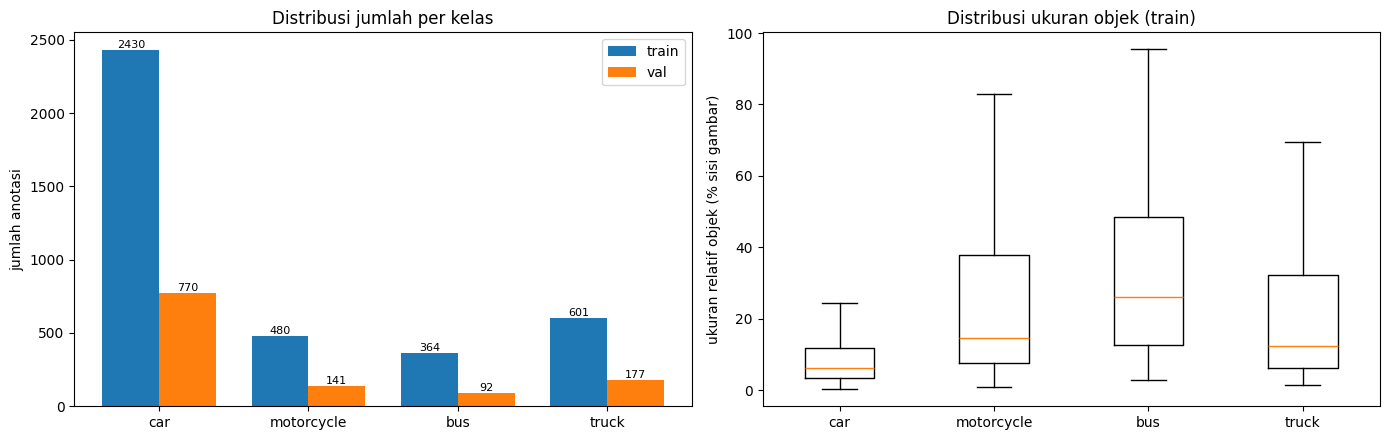

jumlah train: {'bus': 364, 'car': 2430, 'motorcycle': 480, 'truck': 601}
jumlah val  : {'truck': 177, 'car': 770, 'motorcycle': 141, 'bus': 92}
ukuran car        : median 6.1%  (min 0.3 / max 100.0)
ukuran motorcycle : median 14.5%  (min 1.0 / max 97.0)
ukuran bus        : median 26.1%  (min 2.9 / max 95.4)
ukuran truck      : median 12.5%  (min 1.4 / max 100.0)


In [6]:
import json, numpy as np, matplotlib.pyplot as plt
from collections import Counter, defaultdict

def load_dist(coco_json):
    d = json.load(open(coco_json))
    id2name = {c['id']: c['name'] for c in d['categories']}
    imgs = {im['id']: im for im in d['images']}
    counts = Counter()
    sizes = defaultdict(list)            # ukuran relatif objek per kelas
    for a in d['annotations']:
        name = id2name[a['category_id']]
        counts[name] += 1
        im = imgs.get(a['image_id'])
        if im:
            x, y, w, h = a['bbox']
            rel = (w * h / (im['width'] * im['height'])) ** 0.5 * 100
            sizes[name].append(rel)
    return counts, sizes

tr_c, tr_s = load_dist(TRAIN_JSON)
va_c, _ = load_dist(VALID_JSON)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

# --- kiri: jumlah per kelas (train vs val) ---
x = np.arange(len(CLASSES)); w = 0.38
b1 = ax[0].bar(x - w/2, [tr_c.get(n, 0) for n in CLASSES], w, label='train')
b2 = ax[0].bar(x + w/2, [va_c.get(n, 0) for n in CLASSES], w, label='val')
ax[0].bar_label(b1, fontsize=8); ax[0].bar_label(b2, fontsize=8)
ax[0].set_xticks(x); ax[0].set_xticklabels(CLASSES)
ax[0].set_ylabel('jumlah anotasi'); ax[0].set_title('Distribusi jumlah per kelas')
ax[0].legend()

# --- kanan: distribusi ukuran objek per kelas (train) ---
data = [tr_s.get(n, [0]) for n in CLASSES]
ax[1].boxplot(data, showfliers=False)
ax[1].set_xticks(range(1, len(CLASSES) + 1)); ax[1].set_xticklabels(CLASSES)
ax[1].set_ylabel('ukuran relatif objek (% sisi gambar)')
ax[1].set_title('Distribusi ukuran objek (train)')

plt.tight_layout(); plt.show()
print('jumlah train:', dict(tr_c))
print('jumlah val  :', dict(va_c))
for n in CLASSES:
    s = tr_s.get(n, [])
    if s:
        print(f'ukuran {n:11s}: median {np.median(s):.1f}%  (min {min(s):.1f} / max {max(s):.1f})')

### 2d) Visualize label sample - contoh gambar + bounding box

Cek mata kepala bahwa anotasi (kotak + label) benar.

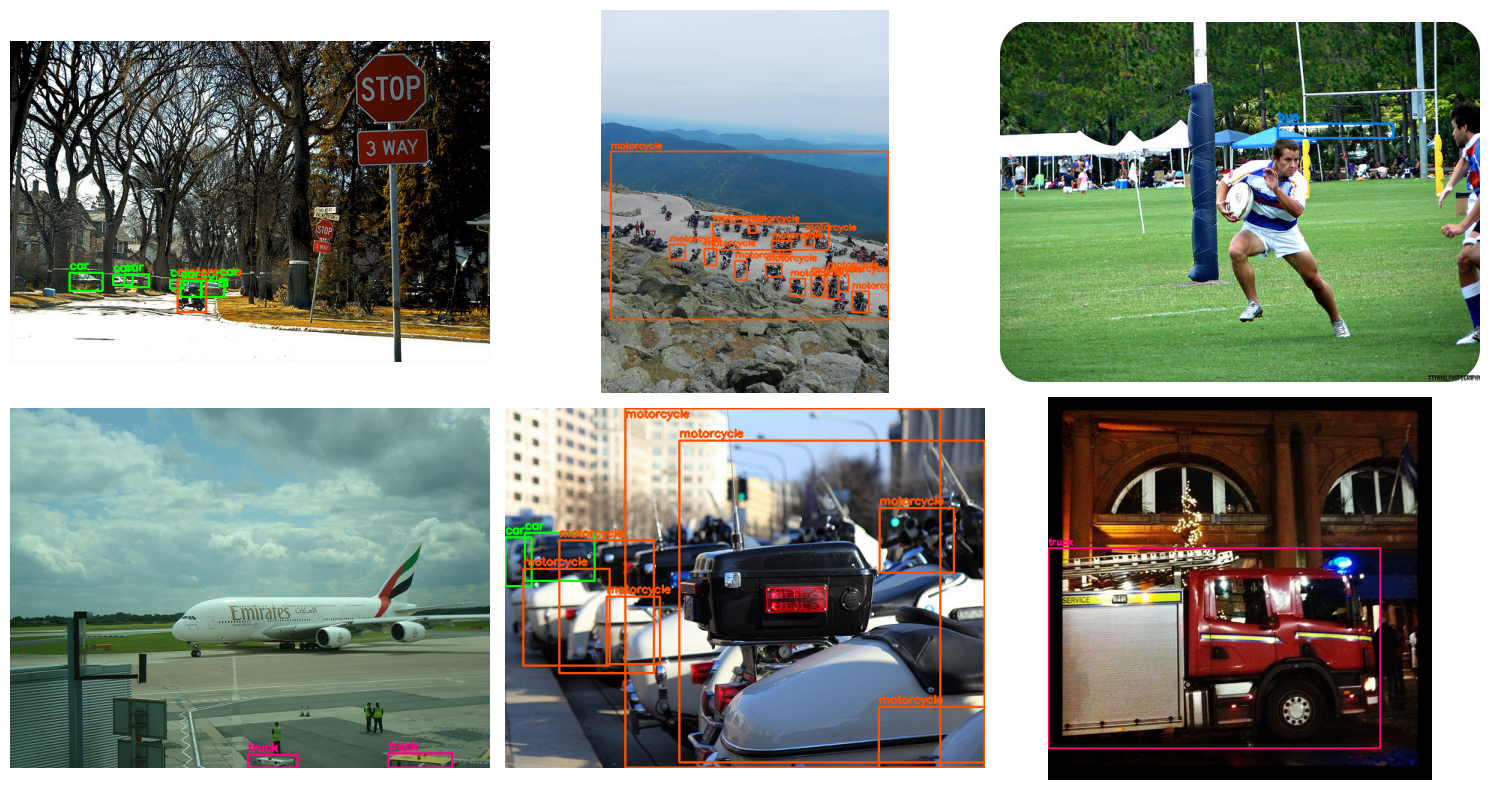

In [7]:
import cv2, json, random
from collections import defaultdict
import matplotlib.pyplot as plt

COL = {'car': (0,255,0), 'motorcycle': (255,80,0), 'bus': (0,128,255), 'truck': (255,0,128)}
d = json.load(open(TRAIN_JSON))
id2name = {c['id']: c['name'] for c in d['categories']}
imgs = {im['id']: im for im in d['images']}
anns_by_img = defaultdict(list)
for a in d['annotations']:
    anns_by_img[a['image_id']].append(a)

sample = random.Random(1).sample(list(anns_by_img), min(6, len(anns_by_img)))
plt.figure(figsize=(15, 8))
for i, iid in enumerate(sample):
    im = imgs[iid]
    img = cv2.cvtColor(cv2.imread(f"{TRAIN_IMG_DIR}/{im['file_name']}"), cv2.COLOR_BGR2RGB)
    for a in anns_by_img[iid]:
        x, y, bw, bh = [int(v) for v in a['bbox']]
        name = id2name[a['category_id']]
        c = COL.get(name, (0,255,0))
        cv2.rectangle(img, (x, y), (x+bw, y+bh), c, 2)
        cv2.putText(img, name, (x, max(12, y-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, c, 2)
    plt.subplot(2, 3, i+1); plt.imshow(img); plt.axis('off')
plt.tight_layout(); plt.show()

## 3) Slicing Aided Fine-tuning - potong dataset jadi ubin

In [8]:
import json, os, shutil
from PIL import Image
shutil.rmtree('/content/sliced', ignore_errors=True)   # bersihkan slice lama (aman diulang)

def sanitize(coco_json, img_dir):
    """Buang gambar rusak/hilang dari labels.json (+disk) agar slice_coco aman."""
    d = json.load(open(coco_json))
    good_ids, good_imgs = set(), []
    for im in d['images']:
        p = os.path.join(img_dir, im['file_name'])
        ok = os.path.exists(p)
        if ok:
            try:
                with Image.open(p) as x:
                    x.load()
            except Exception:
                ok = False
        if ok:
            good_ids.add(im['id']); good_imgs.append(im)
        elif os.path.exists(p):
            os.remove(p)
    buang = len(d['images']) - len(good_imgs)
    d['images'] = good_imgs
    d['annotations'] = [a for a in d['annotations'] if a['image_id'] in good_ids]
    json.dump(d, open(coco_json, 'w'))
    print(f'{coco_json}: {len(good_imgs)} gambar valid dipakai (buang {buang} rusak/hilang)')

sanitize(TRAIN_JSON, TRAIN_IMG_DIR)
sanitize(VALID_JSON, VALID_IMG_DIR)

from sahi.slicing import slice_coco

SLICE = 640          # ukuran ubin (perkecil ke 512 untuk objek lebih kecil)
OVERLAP = 0.2        # tumpang-tindih antar-ubin (0.2-0.3 untuk motor)

# slice_coco mengembalikan (coco_dict, path_json). Pakai path balikannya (nama
# file diberi sufiks dimensi oleh SAHI, jadi jangan di-hardcode).
_, TRAIN_SLICED_JSON = slice_coco(
    coco_annotation_file_path=TRAIN_JSON, image_dir=TRAIN_IMG_DIR,
    output_coco_annotation_file_name='train_sliced',
    output_dir='/content/sliced/train',
    slice_height=SLICE, slice_width=SLICE,
    overlap_height_ratio=OVERLAP, overlap_width_ratio=OVERLAP,
    min_area_ratio=0.1, verbose=True)

_, VALID_SLICED_JSON = slice_coco(
    coco_annotation_file_path=VALID_JSON, image_dir=VALID_IMG_DIR,
    output_coco_annotation_file_name='valid_sliced',
    output_dir='/content/sliced/valid',
    slice_height=SLICE, slice_width=SLICE,
    overlap_height_ratio=OVERLAP, overlap_width_ratio=OVERLAP,
    min_area_ratio=0.1, verbose=True)

print('train json:', TRAIN_SLICED_JSON)
print('val json  :', VALID_SLICED_JSON)
print('selesai memotong dataset')

/content/coco_sub/train/labels.json: 1000 gambar valid dipakai (buang 0 rusak/hilang)
/content/coco_sub/valid/labels.json: 300 gambar valid dipakai (buang 0 rusak/hilang)


Streaming output truncated to the last 5000 lines.
2026-06-23 10:20:34,657 - sahi - INFO - sliced image path: /content/sliced/train/000000561527_467_0_0_640_480.png (slicing.py:336)
INFO:sahi:sliced image path: /content/sliced/train/000000561527_467_0_0_640_480.png
2026-06-23 10:20:34,659 - sahi - INFO - Num slices: 1 slice_height: 480 slice_width: 640 (slicing.py:428)
INFO:sahi:Num slices: 1 slice_height: 480 slice_width: 640
 47%|████▋     | 468/1000 [00:58<01:03,  8.42it/s]2026-06-23 10:20:34,669 - sahi - INFO - image.shape: (640, 463) (slicing.py:344)
INFO:sahi:image.shape: (640, 463)
2026-06-23 10:20:34,780 - sahi - INFO - sliced image path: /content/sliced/train/000000001232_468_0_0_640_463.png (slicing.py:336)
INFO:sahi:sliced image path: /content/sliced/train/000000001232_468_0_0_640_463.png
2026-06-23 10:20:34,782 - sahi - INFO - Num slices: 1 slice_height: 463 slice_width: 640 (slicing.py:428)
INFO:sahi:Num slices: 1 slice_height: 463 slice_width: 640
 47%|████▋     | 469/100

train json: /content/sliced/train/train_sliced_coco.json
val json  : /content/sliced/valid/valid_sliced_coco.json
selesai memotong dataset


## 4) Konversi COCO ter-slice -> format YOLO

In [9]:
# Konversi COCO ter-slice -> format YOLO (manual, tak tergantung versi SAHI)
import os, json, glob, shutil, yaml
from collections import defaultdict

CLASSES = ['car', 'motorcycle', 'bus', 'truck']
BASE = '/content/yolo_sliced'
shutil.rmtree(BASE, ignore_errors=True)

def find_sliced_json(d):
    g = sorted(glob.glob(f'{d}/*.json'))
    if not g:
        raise FileNotFoundError(f'tak ada json hasil slice di {d} - jalankan sel slicing dulu')
    return g[0]

# pakai path dari sel slicing bila ada; kalau tidak, cari otomatis
TRAIN_SLICED_JSON = globals().get('TRAIN_SLICED_JSON') or find_sliced_json('/content/sliced/train')
VALID_SLICED_JSON = globals().get('VALID_SLICED_JSON') or find_sliced_json('/content/sliced/valid')
print('train json:', TRAIN_SLICED_JSON)
print('val json  :', VALID_SLICED_JSON)

def coco_to_yolo(coco_json, img_src_dir, split):
    d = json.load(open(coco_json))
    out_img = f'{BASE}/images/{split}'
    out_lbl = f'{BASE}/labels/{split}'
    os.makedirs(out_img, exist_ok=True); os.makedirs(out_lbl, exist_ok=True)
    anns = defaultdict(list)
    for a in d['annotations']:
        anns[a['image_id']].append(a)
    n = 0
    for im in d['images']:
        fn = im['file_name']
        src = os.path.join(img_src_dir, fn)
        if not os.path.exists(src):
            continue
        base = os.path.basename(fn)
        shutil.copy(src, os.path.join(out_img, base))
        W, H = im['width'], im['height']
        rows = []
        for a in anns.get(im['id'], []):
            x, y, w, h = a['bbox']
            cx, cy = (x + w/2)/W, (y + h/2)/H
            rows.append(f"{a['category_id']} {cx:.6f} {cy:.6f} {w/W:.6f} {h/H:.6f}")
        stem = os.path.splitext(base)[0]
        with open(os.path.join(out_lbl, stem + '.txt'), 'w') as f:
            f.write('\n'.join(rows))
        n += 1
    print(f'{split}: {n} gambar -> YOLO')

coco_to_yolo(TRAIN_SLICED_JSON, '/content/sliced/train', 'train')
coco_to_yolo(VALID_SLICED_JSON, '/content/sliced/valid', 'val')

data = {'path': BASE, 'train': 'images/train', 'val': 'images/val',
        'names': {i: n for i, n in enumerate(CLASSES)}}
data_yml = f'{BASE}/data.yaml'
with open(data_yml, 'w') as f:
    yaml.safe_dump(data, f, sort_keys=False)
print('data.yaml:', data_yml)
print(open(data_yml).read())

train json: /content/sliced/train/train_sliced_coco.json
val json  : /content/sliced/valid/valid_sliced_coco.json
train: 1000 gambar -> YOLO
val: 300 gambar -> YOLO
data.yaml: /content/yolo_sliced/data.yaml
path: /content/yolo_sliced
train: images/train
val: images/val
names:
  0: car
  1: motorcycle
  2: bus
  3: truck



> Pastikan `names` di data.yml = `['car','motorcycle','bus','truck']`. App memetakan ke label Indonesia otomatis (car->mobil, motorcycle->motor, bus->bus, truck->truk).

## 5) Latih YOLOv8

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')      # detection; ganti yolov8s-seg.pt bila butuh mask
model.train(
    data=data_yml,
    imgsz=SLICE,
    epochs=100,
    batch=16,
    patience=20,
    name='vehicle_sahi',
    mosaic=1.0, scale=0.5, fliplr=0.5,
)
BEST = 'runs/detect/vehicle_sahi/weights/best.pt'
RUN_DIR = os.path.dirname(os.path.dirname(BEST))
print('model terbaik:', BEST)

## 6) Validasi

In [ ]:
metrics = YOLO(BEST).val(data=data_yml, imgsz=SLICE)
print('mAP50-95:', metrics.box.map)
print('mAP50  :', metrics.box.map50)
# perhatikan baris 'motorcycle' pada tabel per-kelas di atas

## 7) Grafik training - loss, val loss, mAP, precision & recall

Dibaca dari `results.csv` yang ditulis ultralytics tiap epoch.

In [ ]:
import pandas as pd, matplotlib.pyplot as plt

df = pd.read_csv(f'{RUN_DIR}/results.csv')
df.columns = [c.strip() for c in df.columns]
ep = df['epoch']

def plot(ax, cols, title):
    for c in cols:
        if c in df.columns:
            ax.plot(ep, df[c], label=c.split('/')[-1])
    ax.set_title(title); ax.set_xlabel('epoch'); ax.grid(alpha=0.3); ax.legend()

fig, ax = plt.subplots(2, 2, figsize=(13, 9))
plot(ax[0,0], ['train/box_loss','train/cls_loss','train/dfl_loss'], 'Training loss')
plot(ax[0,1], ['val/box_loss','val/cls_loss','val/dfl_loss'], 'Validation loss')
plot(ax[1,0], ['metrics/mAP50(B)','metrics/mAP50-95(B)'], 'mAP')
plot(ax[1,1], ['metrics/precision(B)','metrics/recall(B)'], 'Precision & Recall')
plt.tight_layout(); plt.show()

# ultralytics juga menyimpan ringkasan otomatis:
from IPython.display import Image, display
display(Image(f'{RUN_DIR}/results.png'))

## 8) Prediksi dengan model baru

Jalankan model hasil training pada satu gambar uji (otomatis ambil gambar val pertama; ganti `TEST_IMG` dengan **screenshot CCTV** untuk uji nyata).

In [ ]:
import glob, cv2
import matplotlib.pyplot as plt
from collections import Counter
from ultralytics import YOLO

TEST_IMG = sorted(glob.glob(f'{VALID_IMG_DIR}/*.jpg'))[0]   # ganti dgn screenshot CCTV
best_model = YOLO(BEST)
res = best_model.predict(TEST_IMG, conf=0.25, imgsz=SLICE, verbose=False)[0]

plotted = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(11, 7)); plt.imshow(plotted); plt.axis('off')
plt.title('Prediksi model baru'); plt.show()

cnt = Counter(best_model.names[int(b.cls)] for b in res.boxes)
print('Jumlah deteksi per kelas:', dict(cnt))

## 9) Inference SAHI - perbandingan biasa vs ter-slice

SAHI ter-slice biasanya menangkap **lebih banyak motor kecil** daripada deteksi biasa.

In [ ]:
# Inference SAHI - perbandingan deteksi biasa vs ter-slice
import os, glob, torch
from collections import Counter
from sahi import AutoDetectionModel
from sahi.predict import get_prediction, get_sliced_prediction

# Gambar uji: pakai TEST_IMG yang sudah ada & valid; jika tidak, ambil val pertama.
# Ganti dengan screenshot CCTV untuk uji nyata.
TEST_IMG = globals().get('TEST_IMG', '')
if not (isinstance(TEST_IMG, str) and os.path.exists(TEST_IMG)):
    TEST_IMG = sorted(glob.glob(f'{VALID_IMG_DIR}/*.jpg'))[0]
print('gambar uji:', TEST_IMG)

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
det = AutoDetectionModel.from_pretrained(
    model_type='ultralytics', model_path=BEST,
    confidence_threshold=0.25, device=device)

pred_plain = get_prediction(TEST_IMG, det)
pred_sahi = get_sliced_prediction(
    TEST_IMG, det,
    slice_height=SLICE, slice_width=SLICE,
    overlap_height_ratio=OVERLAP, overlap_width_ratio=OVERLAP)

pred_plain.export_visuals(export_dir='/content/out_plain')
pred_sahi.export_visuals(export_dir='/content/out_sahi')

def ringkas(p):
    return dict(Counter(o.category.name for o in p.object_prediction_list))

print('Deteksi BIASA:', ringkas(pred_plain), '| total', len(pred_plain.object_prediction_list))
print('Deteksi SAHI :', ringkas(pred_sahi), '| total', len(pred_sahi.object_prediction_list))

from IPython.display import Image, display
print('--- Biasa ---'); display(Image('/content/out_plain/prediction_visual.png'))
print('--- SAHI ---');  display(Image('/content/out_sahi/prediction_visual.png'))

## 10) Prediksi gambar upload (mis. foto motor)

Upload gambar -> prediksi dengan model. Untuk gambar **malam / CCTV gelap**, aktifkan opsi:
- `ENHANCE=True` -> brighten + CLAHE (angkat objek gelap)
- `CONF` rendah (0.1 / 0.05) -> malam hari model ragu
- `SLICE_INFER` kecil (320/256) -> motor kecil jadi relatif besar

> **Jujur:** kalau model belum dilatih pada data **malam/CCTV**, sebagian gambar tetap sulit walau di-enhance. Solusi tuntas = tambah data domain (frame ATCS malam) ke training. Section ini memaksimalkan peluang dengan model yang ada.

In [ ]:
import os, cv2, torch, numpy as np
from collections import Counter
from google.colab import files
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from IPython.display import Image, display

# ---- setelan (sesuaikan untuk gambar malam) ----
MODEL_PATH  = BEST     # ganti ke model lain bila perlu, mis. 'yolov8s.pt'
CONF        = 0.10     # malam: turunkan ke 0.05
SLICE_INFER = 320      # ubin inference; kecil = objek kecil lebih tertangkap
OVERLAP_INF = 0.2
ENHANCE     = True     # brighten + CLAHE untuk gambar gelap

def enhance_night(path):
    """Angkat kecerahan + kontras lokal (CLAHE) untuk gambar gelap."""
    img = cv2.imread(path)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8)).apply(l)
    out = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2BGR)
    out = cv2.convertScaleAbs(out, alpha=1.2, beta=20)   # sedikit lebih terang
    p2 = '/content/_enh.jpg'
    cv2.imwrite(p2, out)
    return p2

uploaded = files.upload()    # << pilih gambar di sini
paths = list(uploaded.keys())

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
det = AutoDetectionModel.from_pretrained(
    model_type='ultralytics', model_path=MODEL_PATH,
    confidence_threshold=CONF, device=device)

def ringkas(p):
    return dict(Counter(o.category.name for o in p.object_prediction_list))

for img in paths:
    print('=' * 50); print('Gambar:', img)
    use = enhance_night(img) if ENHANCE else img
    if ENHANCE:
        print('--- setelah enhance ---'); display(Image(use))
    res = get_sliced_prediction(use, det,
                                slice_height=SLICE_INFER, slice_width=SLICE_INFER,
                                overlap_height_ratio=OVERLAP_INF, overlap_width_ratio=OVERLAP_INF)
    res.export_visuals(export_dir='/content/up_out')
    n = len(res.object_prediction_list)
    print('Deteksi:', ringkas(res), '| total', n)
    if n == 0:
        print('  (0 deteksi -> coba CONF=0.05, SLICE_INFER=256, atau model perlu dilatih data malam)')
    display(Image('/content/up_out/prediction_visual.png'))

## 11) Unduh model untuk dipakai di aplikasi

Taruh best.pt di `models/` project, mis. `best_vehicle_sahi.pt`, lalu set `MODEL=best_vehicle_sahi.pt`.

In [ ]:
from google.colab import files
import shutil
shutil.copy(BEST, '/content/best_vehicle_sahi.pt')
files.download('/content/best_vehicle_sahi.pt')

## Tips menambah akurasi motor
- **Perbanyak contoh motorcycle** & seimbangkan kelas (lihat sel 2c) - paling berpengaruh.
- Slice lebih kecil: SLICE=512, OVERLAP=0.3.
- Turunkan confidence_threshold (0.15-0.25) saat inference.
- Untuk CCTV: gabungkan COCO (baseline) dengan data domain-CCTV.
- Saat dipakai di app, gunakan **SAHI sliced inference** untuk hasil maksimal (lebih berat di CPU).